# Por que prompting funciona: la mecanica probabilistica

Este notebook construye una intuicion visual del mecanismo real de un LLM:
tokens, embeddings, distribucion de probabilidad y temperatura.
No requiere matematicas formales: solo necesitas entender que el modelo **predice**, no **entiende**.

In [1]:
# Dependencias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Fig 01 - El pipeline de predicción de un LLM

Cada vez que el modelo genera un token, recorre exactamente este camino:
1. **Tokenización**: texto -> IDs numéricos
2. **Embedding**: cada ID -> vector de alta dimension
3. **Transformer**: los embeddings interactuan (atencion)
4. **Logits**: un numero por cada token del vocabulario
5. **Softmax**: los logits se convierten en probabilidades (suman 1)
6. **Muestreo**: se elige el siguiente token segun esa distribucion

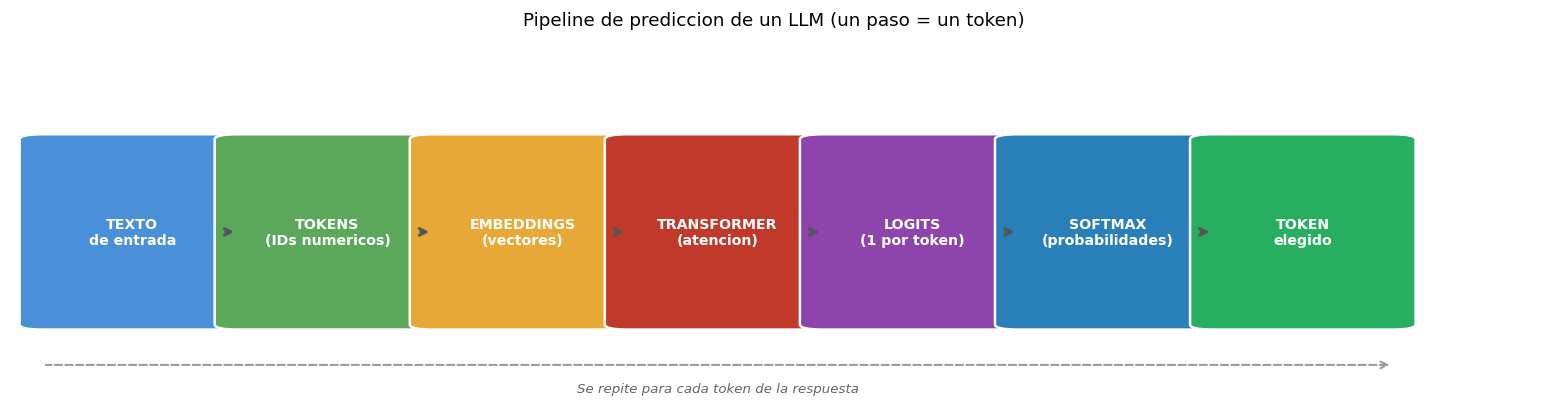

fig01 guardada


In [2]:
# fig01 - pipeline de prediccion
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')

pasos = [
    ("TEXTO\nde entrada", "#4A90D9"),
    ("TOKENS\n(IDs numericos)", "#5BA85A"),
    ("EMBEDDINGS\n(vectores)", "#E8A838"),
    ("TRANSFORMER\n(atencion)", "#C0392B"),
    ("LOGITS\n(1 por token)", "#8E44AD"),
    ("SOFTMAX\n(probabilidades)", "#2980B9"),
    ("TOKEN\nelegido", "#27AE60"),
]

x0, ancho, alto = 0.02, 0.118, 0.55
y0 = 0.2
gap = 0.01

for i, (label, color) in enumerate(pasos):
    x = x0 + i * (ancho + gap)
    rect = mpatches.FancyBboxPatch(
        (x, y0), ancho, alto,
        boxstyle="round,pad=0.015",
        facecolor=color, edgecolor="white", linewidth=1.5,
        transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(x + ancho/2, y0 + alto/2, label,
            ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold',
            transform=ax.transAxes)
    if i < len(pasos) - 1:
        ax.annotate("", xy=(x + ancho + gap, y0 + alto/2),
                    xytext=(x + ancho, y0 + alto/2),
                    xycoords="axes fraction", textcoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.8))

# etiqueta de ciclo
ax.annotate("",
    xy=(x0, y0 - 0.12), xytext=(x0 + (ancho + gap) * 6 + ancho, y0 - 0.12),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=dict(arrowstyle="<-", color="#999", lw=1.2, linestyle="dashed"))
ax.text(x0 + (ancho + gap) * 3 + ancho/2, y0 - 0.19,
    "Se repite para cada token de la respuesta",
    ha='center', va='center', fontsize=8, color='#666',
    style='italic', transform=ax.transAxes)

ax.set_title("Pipeline de prediccion de un LLM (un paso = un token)",
             fontsize=11, pad=18)
plt.tight_layout()
plt.savefig('images/B06A_fig01.png', bbox_inches='tight')
plt.show()
print("fig01 guardada")

## Fig 02 - El espacio de embeddings: proximidad semántica

Los embeddings son vectores de miles de dimensiones. Para visualizarlos,
los proyectamos a 2D. La propiedad clave: **tokens semánticamente similares
estan cerca en ese espacio**. Eso no fue diseñado: emergio del entrenamiento.

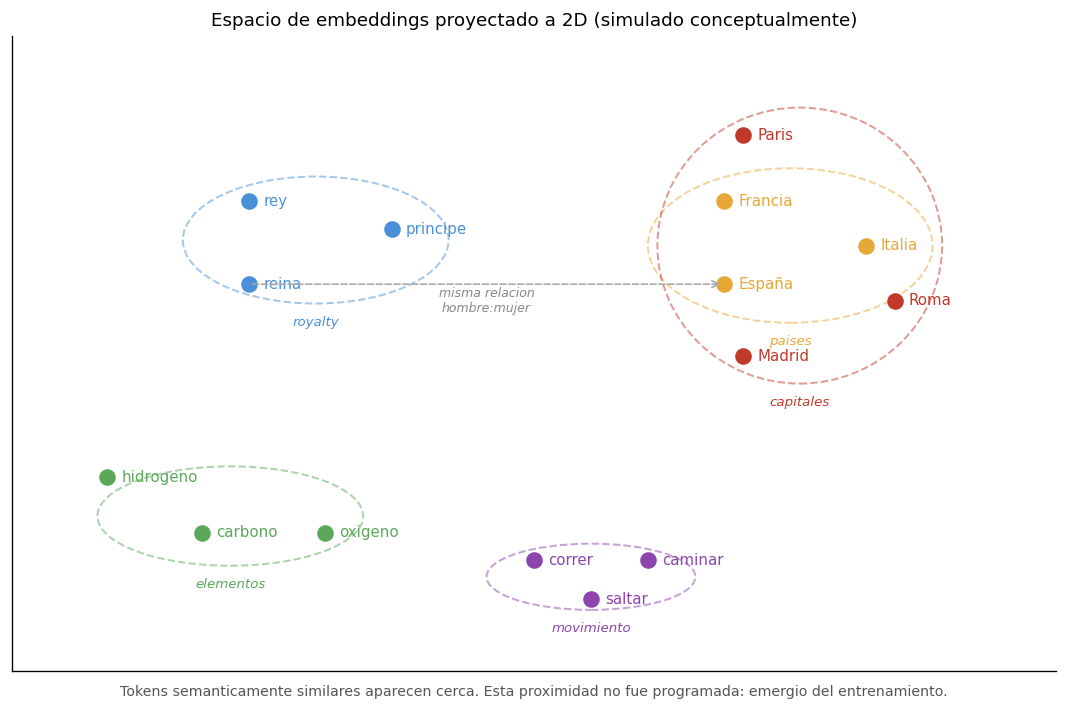

fig02 guardada


In [3]:
# fig02 - espacio embedding 2D simulado

# Coordenadas 2D simuladas (representan relaciones semanticas reales)
palabras = {
    # royalty cluster
    "rey":    (0.2,  0.8),
    "reina":  (0.2,  0.65),
    "principe": (0.35, 0.75),
    # paises cluster
    "Francia": (0.7, 0.8),
    "España":  (0.7, 0.65),
    "Italia":  (0.85, 0.72),
    # capitales cluster
    "Paris":   (0.72, 0.92),
    "Madrid":  (0.72, 0.52),
    "Roma":    (0.88, 0.62),
    # ciencia cluster
    "carbono": (0.15, 0.2),
    "oxigeno": (0.28, 0.2),
    "hidrogeno": (0.05, 0.3),
    # verbs cluster
    "correr":  (0.5, 0.15),
    "caminar": (0.62, 0.15),
    "saltar":  (0.56, 0.08),
}

colores = {
    "rey": "#4A90D9", "reina": "#4A90D9", "principe": "#4A90D9",
    "Francia": "#E8A838", "España": "#E8A838", "Italia": "#E8A838",
    "Paris": "#C0392B", "Madrid": "#C0392B", "Roma": "#C0392B",
    "carbono": "#5BA85A", "oxigeno": "#5BA85A", "hidrogeno": "#5BA85A",
    "correr": "#8E44AD", "caminar": "#8E44AD", "saltar": "#8E44AD",
}

fig, ax = plt.subplots(figsize=(9, 6))

for palabra, (x, y) in palabras.items():
    color = colores[palabra]
    ax.scatter(x, y, s=80, color=color, zorder=3)
    ax.text(x + 0.015, y, palabra, fontsize=9, va='center', color=color)

# flecha analogia rey-reina : Francia-España
ax.annotate("", xy=(0.7, 0.65), xytext=(0.2, 0.65),
    arrowprops=dict(arrowstyle="->", color="#aaa", lw=1.0, linestyle="dashed"))
ax.text(0.45, 0.6, "misma relacion\nhombre:mujer", ha='center',
        fontsize=7.5, color='#888', style='italic')

# elipses de cluster
from matplotlib.patches import Ellipse
clusters = [
    (0.27, 0.73, 0.28, 0.23, "#4A90D9", "royalty"),
    (0.77, 0.72, 0.30, 0.28, "#E8A838", "paises"),
    (0.78, 0.72, 0.30, 0.50, "#C0392B", "capitales"),
    (0.18, 0.23, 0.28, 0.18, "#5BA85A", "elementos"),
    (0.56, 0.12, 0.22, 0.12, "#8E44AD", "movimiento"),
]
for cx, cy, w, h, c, lbl in clusters:
    e = Ellipse((cx, cy), w, h, angle=0, fill=False,
                edgecolor=c, linestyle="--", linewidth=1.2, alpha=0.5)
    ax.add_patch(e)
    ax.text(cx, cy - h/2 - 0.04, lbl, ha='center',
            fontsize=8, color=c, style='italic')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Espacio de embeddings proyectado a 2D (simulado conceptualmente)",
             fontsize=11)
ax.text(0.5, -0.04,
    "Tokens semanticamente similares aparecen cerca."
    " Esta proximidad no fue programada: emergio del entrenamiento.",
    ha='center', fontsize=8.5, color='#555', transform=ax.transAxes)
plt.tight_layout()
plt.savefig('images/B06A_fig02.png', bbox_inches='tight')
plt.show()
print("fig02 guardada")

## Fig 03 - Temperatura: cuanta aleatoriedad se inyecta

La temperatura controla como de "plana" o "picuda" es la distribución de probabilidad
antes de muestrear el siguiente token.

- **T baja (0.1)**: el modelo casi siempre elige el token mas probable. Predecible.
- **T media (0.7)**: balance entre coherencia y variedad. El default habitual.
- **T alta (1.5)**: cualquier token tiene mas oportunidad. Creativo pero impredecible.

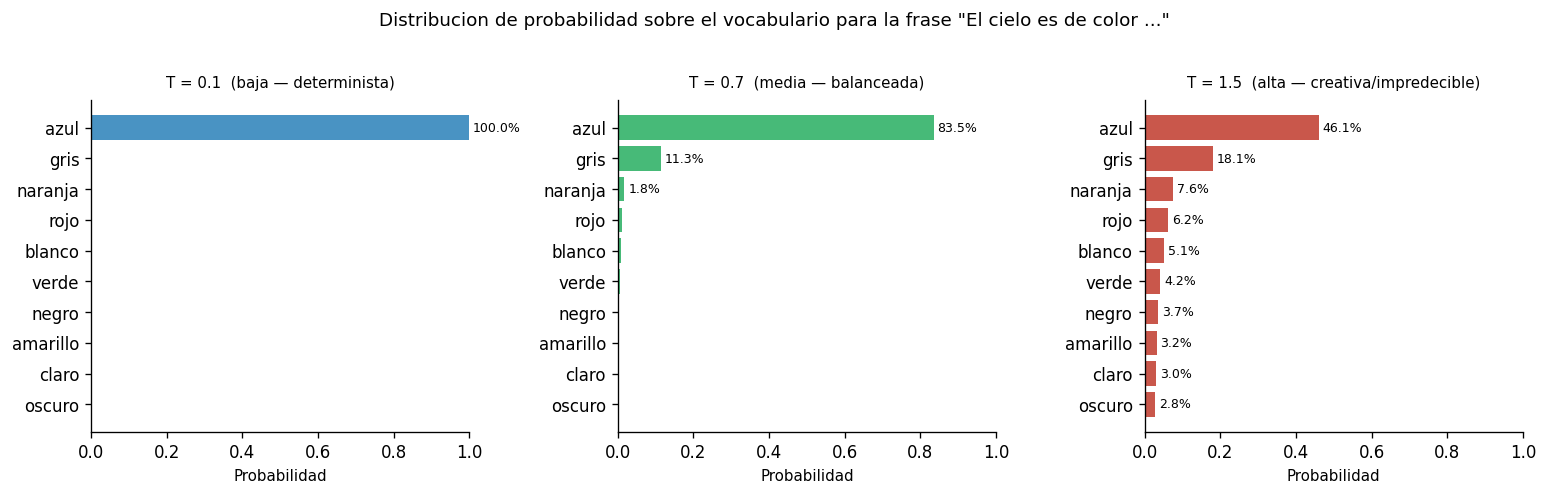

fig03 guardada


In [4]:
# fig03 - efecto temperatura sobre distribucion top-10

tokens_top = ["azul", "gris", "naranja", "rojo", "blanco",
              "verde", "negro", "amarillo", "claro", "oscuro"]

def softmax(logits, T):
    l = np.array(logits) / T
    e = np.exp(l - np.max(l))
    return e / e.sum()

# logits base (simulados - el token "azul" es el mas probable)
logits_base = [4.2, 2.8, 1.5, 1.2, 0.9, 0.6, 0.4, 0.2, 0.1, 0.0]

temperaturas = [0.1, 0.7, 1.5]
colores_t = ["#2980B9", "#27AE60", "#C0392B"]
titulos_t = ["T = 0.1  (baja - determinista)", "T = 0.7  (media - balanceada)",
             "T = 1.5  (alta - creativa/impredecible)"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, T, color, titulo in zip(axes, temperaturas, colores_t, titulos_t):
    probs = softmax(logits_base, T)
    bars = ax.barh(tokens_top[::-1], probs[::-1], color=color, alpha=0.85)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Probabilidad", fontsize=9)
    ax.set_title(titulo, fontsize=9, pad=8)
    # etiqueta porcentaje
    for bar, p in zip(bars, probs[::-1]):
        if p > 0.015:
            ax.text(p + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{p:.1%}", va='center', fontsize=7.5)

fig.suptitle(
    'Distribucion de probabilidad sobre el vocabulario para la frase'
    ' "El cielo es de color ..."',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('images/B06A_fig03.png', bbox_inches='tight')
plt.show()
print("fig03 guardada")

## Fig 04 - El contexto cambia la distribución

El mismo fragmento de texto produce distribuciones completamente distintas
segun el contexto que lo precede. Esto explica por que el contexto del prompt
es tan critico como las instrucciones explicitas.

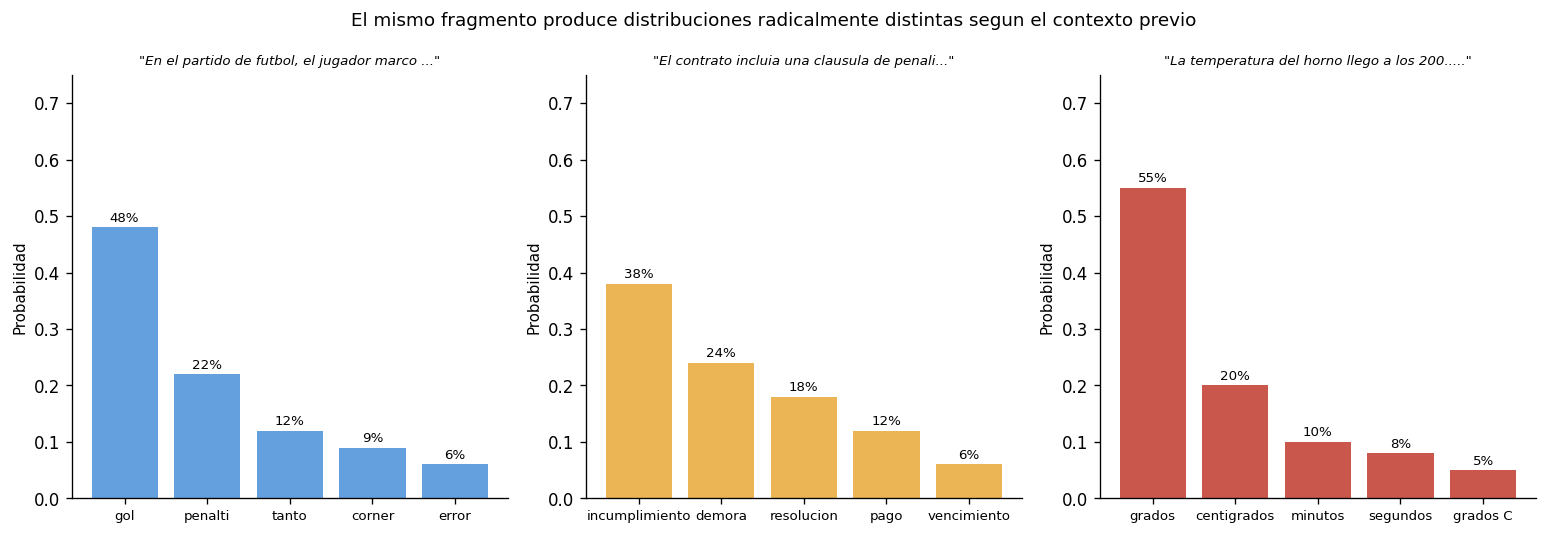

fig04 guardada


In [5]:
# fig04 - misma palabra, distintos contextos -> distintas top-5 probabilidades

contextos = [
    "En el partido de futbol, el jugador marco un...",
    "El contrato incluia una clausula de penalizacion por...",
    "La temperatura del horno llego a los 200...",
]

# Top-5 tokens simulados para cada contexto (representativos, no de modelo real)
tops = [
    [("gol",      0.48), ("penalti",  0.22), ("tanto",    0.12),
     ("corner",   0.09), ("error",    0.06)],
    [("incumplimiento", 0.38), ("demora", 0.24), ("resolucion", 0.18),
     ("pago", 0.12), ("vencimiento", 0.06)],
    [("grados", 0.55), ("centigrados", 0.20), ("minutos", 0.10),
     ("segundos", 0.08), ("grados C", 0.05)],
]

colores_ctx = ["#4A90D9", "#E8A838", "#C0392B"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, ctx, top5, color in zip(axes, contextos, tops, colores_ctx):
    tokens = [t for t, _ in top5]
    probs  = [p for _, p in top5]
    bars = ax.bar(tokens, probs, color=color, alpha=0.85)
    ax.set_ylim(0, 0.75)
    ax.set_ylabel("Probabilidad", fontsize=9)
    # contexto como titulo truncado
    titulo = ctx if len(ctx) < 42 else ctx[:42] + "..."
    ax.set_title(f'"{titulo}"', fontsize=8, pad=6, style='italic')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, p + 0.01,
                f"{p:.0%}", ha='center', fontsize=8)
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle(
    "El mismo fragmento produce distribuciones radicalmente distintas"
    " segun el contexto previo",
    fontsize=11)
plt.tight_layout()
plt.savefig('images/B06A_fig04.png', bbox_inches='tight')
plt.show()
print("fig04 guardada")

## Fig 05 - Sycophancy y truncamiento de distribución

Dos fallos probabilísticos clásicos:

- **Sycophancy**: cuando el prompt contiene una afirmacion (aunque sea erronea),
  el modelo tiende a validarla. El entrenamiento con feedback humano lo refuerza.
- **Truncamiento**: un prompt con demasiadas restricciones colapsa la distribución
  en una zona tan estrecha que el modelo viola alguna de las reglas inevitablemente.

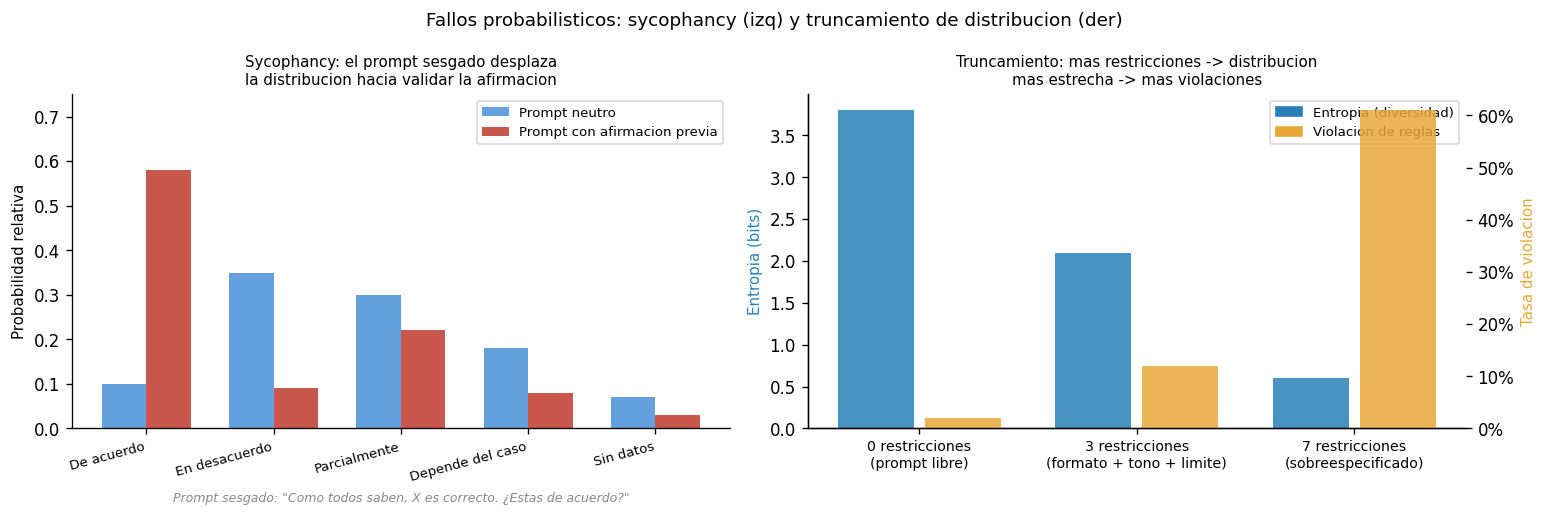

fig05 guardada


In [6]:
# fig05 - sycophancy y truncamiento de distribucion

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Subplot izquierdo: sycophancy ---
ax1 = axes[0]

respuestas_neutro = [
    ("De acuerdo", 0.10),
    ("En desacuerdo", 0.35),
    ("Parcialmente", 0.30),
    ("Depende del caso", 0.18),
    ("Sin datos", 0.07),
]
respuestas_sesgado = [
    ("De acuerdo", 0.58),
    ("En desacuerdo", 0.09),
    ("Parcialmente", 0.22),
    ("Depende del caso", 0.08),
    ("Sin datos", 0.03),
]

cats = [r for r, _ in respuestas_neutro]
probs_n = [p for _, p in respuestas_neutro]
probs_s = [p for _, p in respuestas_sesgado]
x = np.arange(len(cats))
w = 0.35

ax1.bar(x - w/2, probs_n, w, label='Prompt neutro', color='#4A90D9', alpha=0.85)
ax1.bar(x + w/2, probs_s, w, label='Prompt con afirmacion previa', color='#C0392B', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(cats, fontsize=8, rotation=15, ha='right')
ax1.set_ylim(0, 0.75)
ax1.set_ylabel("Probabilidad relativa", fontsize=9)
ax1.set_title("Sycophancy: el prompt sesgado desplaza\nla distribucion hacia validar la afirmacion",
              fontsize=9)
ax1.legend(fontsize=8)
ax1.text(0.5, -0.22,
    "Prompt sesgado: \"Como todos saben, X es correcto. ¿Estas de acuerdo?\"",
    ha='center', fontsize=7.5, color='#888', style='italic',
    transform=ax1.transAxes)

# --- Subplot derecho: truncamiento ---
ax2 = axes[1]

restricciones = [
    "0 restricciones\n(prompt libre)",
    "3 restricciones\n(formato + tono + limite)",
    "7 restricciones\n(sobreespecificado)",
]
# Entropia simulada (bits) - cuanto mas restricciones, menor entropia
entropias = [3.8, 2.1, 0.6]
# Tasa de violacion de alguna regla
violaciones = [0.02, 0.12, 0.61]

x2 = np.arange(len(restricciones))
ax2b = ax2.twinx()

bars_e = ax2.bar(x2 - 0.2, entropias, 0.35, color='#2980B9', alpha=0.85,
                 label='Entropia de la distribucion (bits)')
bars_v = ax2b.bar(x2 + 0.2, violaciones, 0.35, color='#E8A838', alpha=0.85,
                  label='Tasa de violacion de alguna regla')

ax2.set_xticks(x2)
ax2.set_xticklabels(restricciones, fontsize=8.5)
ax2.set_ylabel("Entropia (bits)", fontsize=9, color='#2980B9')
ax2b.set_ylabel("Tasa de violacion", fontsize=9, color='#E8A838')
ax2b.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_title("Truncamiento: mas restricciones -> distribucion\nmas estrecha -> mas violaciones",
              fontsize=9)

lineas = [mpatches.Patch(color='#2980B9', label='Entropia (diversidad)'),
          mpatches.Patch(color='#E8A838', label='Violacion de reglas')]
ax2.legend(handles=lineas, fontsize=8, loc='upper right')

plt.suptitle(
    "Fallos probabilisticos: sycophancy (izq) y truncamiento de distribucion (der)",
    fontsize=11)
plt.tight_layout()
plt.savefig('images/B06A_fig05.png', bbox_inches='tight')
plt.show()
print("fig05 guardada")

## Resumen - Lo que el ingeniero de prompts debe retener

| Concepto | Lo que implica para el diseño de prompts |
|---|---|
| El modelo predice, no entiende | El fallo no es "no me entendio": es "que distribución activé" |
| Embedding = proximidad semántica | Las palabras del prompt importan: activan zonas distintas del espacio |
| Temperatura baja | Para tareas de precisión: clasificación, extracción, código |
| Temperatura alta | Para brainstorming, variedad, generación creativa |
| Lost in the middle | Instrucciones criticas: al principio y al final del prompt |
| Sycophancy | No incluir afirmaciones previas si quieres evaluacion neutra |
| Truncamiento | Si el modelo ignora reglas: el prompt tiene demasiadas. Priorizar. |

> Un prompt bien diseñado no explica mejor: restringe la distribución de probabilidad
> hacia donde quieres llegar.

---

**Siguiente paso:** Bloque 7 - Prompting como Programación Declarativa.
Con esta base mecánica, el diseño de prompts deja de ser artesania y se convierte
en ingenieria: se sabe que se esta moviendo, por que funciona y como diagnosticar cuando falla.